# Binary Classification
## Predicting Diabetes Using the Pima Indians Diabetes Dataset
### COEG 435/535 : Machine Learning for Engineers
### Fall 2026 — Homework 3

**About the Dataset: Pima Indians Diabetes Database**

This dataset originates from the National Institute of Diabetes and Digestive and Kidney Diseases and has been widely used in medical ML research. It contains 768 instances of female patients (≥21 years old) of Pima Indian heritage residing near Phoenix, Arizona. The goal is to predict whether a patient tests positive for diabetes, based on 8 clinical measurements.

| Detail | Value |
|---|---|
| Instances | 768 |
| Attributes | 8 predictors + 1 binary target |
| Target Variable | 0 → tested_negative, 1 → tested_positive |
| Class Distribution | 500 negative, 268 positive |
| Missing Values | None (encoded as zeros) |

**Attribute List:**
- Number of pregnancies
- Plasma glucose concentration (2-hour oral glucose test)
- Diastolic blood pressure
- Triceps skin fold thickness
- 2-hour serum insulin
- BMI
- Diabetes pedigree function
- Age

**Dataset Link:** https://www.kaggle.com/saurabh00007/diabetescsv

## Table of Contents
1. Data Preprocessing
   - 1.1 Exploratory Data Analysis
   - 1.2 Data Cleaning
   - 1.3 Key Takeaways
   - 1.4 Final Dataset
2. Homework 3 — Random Forest & Decision Tree

## Notebook Setup

In [1]:
import os
print(os.listdir())

['.pythonstartup.py', '.config', 'Social_Network_Ads.csv', '.gitconfig', '.ipython', 'HW1_Problem2_Weather_LogisticRegression-4-.ipynb', 'insurance.csv', '.virtualenvs', 'SVC.ipynb', '.ipynb_checkpoints', '.anaconda', '.jupyter', '.profile', 'HW3-Diabetes.ipynb', '.conda', 'KNN_Class_Excercise.ipynb', 'HW1_Problem2_Weather_LogisticRegression-3.ipynb', 'weatherAUS.csv', '.npm', 'advertising.csv', 'HW1_Problem1_Insurance_Regression.ipynb', 'anaconda_projects', 'DecisionTreeLecture.ipynb', '.local', 'HW1_Problem1_Insurance_Regression-MFranklin.ipynb', 'HW1_Problem2_Weather_LogisticRegression.ipynb', 'README.ipynb', 'HW2-MeghanFranklin-Diabetes.ipynb', '.cache', '.bashrc', '.vimrc']


In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# All HW3 code uses scikit-learn exclusively
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')



## Import Data

In [5]:
# Load the CSV data from Kaggle dataset
file_path = 'diabetes.csv'

try:
    data1 = pd.read_csv(file_path)
    print("CSV file loaded successfully!")
    print(f"Shape: {data1.shape}")
    print("\nFirst 5 rows of the DataFrame:")
    print(data1.head())
    print("\nColumn names:")
    print(data1.columns.tolist())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

CSV file loaded successfully!
Shape: (768, 9)

First 5 rows of the DataFrame:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


## Data Preprocessing

### Label Encoding


In [6]:
# Rename columns to match HW2 naming convention for consistency
data1.columns = ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'class']

# Confirm target column is already binary 0/1
print("Target value counts:")
print(data1['class'].value_counts())
print("\nFirst 5 rows:")
data1.head()

Target value counts:
0    500
1    268
Name: class, dtype: int64

First 5 rows:


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Note:** It is appropriate to have a mix of float and integer columns in this diabetes dataset for several reasons, reflecting the nature of the data itself:

- **Integer Columns:** These typically represent counts, discrete categories, or measurements that are usually reported as whole numbers. For example, you cannot be '2.5 times pregnant' or have an 'age of 31.7 years' in this context.
- **Float Columns:** These columns represent continuous measurements or ratios that can naturally have decimal values. For instance, BMI is a calculated ratio that often includes decimal places (e.g., 25.3), and the Diabetes pedigree function is a genetic score that ranges continuously.

Using correct data types makes the model and its inputs easier to understand and interpret.

### Convert float to integer

In [8]:
# Convert specific columns from float to int
integer_columns = [
    'preg',
    'plas',
    'pres',
    'skin',
    'insu',
    'age'
]

# Apply integer conversion to the specified columns
for col in integer_columns:
    if col in data1.columns and data1[col].dtype == 'float64':
        data1[col] = data1[col].astype('int64')

print("Data types after selective conversion to int64:")
print(data1.info())
data1.head()

Data types after selective conversion to int64:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
# Check for missing values
print('Missing values in each column:')
data1.isnull().sum()

Missing values in each column:


preg     0
plas     0
pres     0
skin     0
insu     0
mass     0
pedi     0
age      0
class    0
dtype: int64

## 1.1 Exploratory Data Analysis

ValueError: cannot convert float NaN to integer

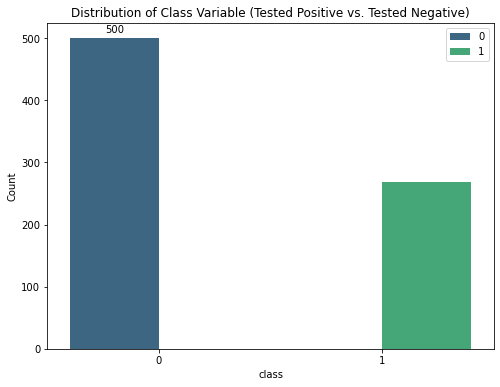

In [11]:
# Get the counts of each class
class_counts = data1['class'].value_counts()

# Map integer labels back to original string labels for better readability in the plot
class_labels = {1: 1, 0: 0}
class_counts.index = class_counts.index.map(class_labels)

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index,
                 palette='viridis')
plt.title('Distribution of Class Variable (Tested Positive vs. Tested Negative)')
plt.xlabel('class')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Add total count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.show()

In [12]:
# Summary Stats
data1.describe()

,preg,plas,pres,skin,insu,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


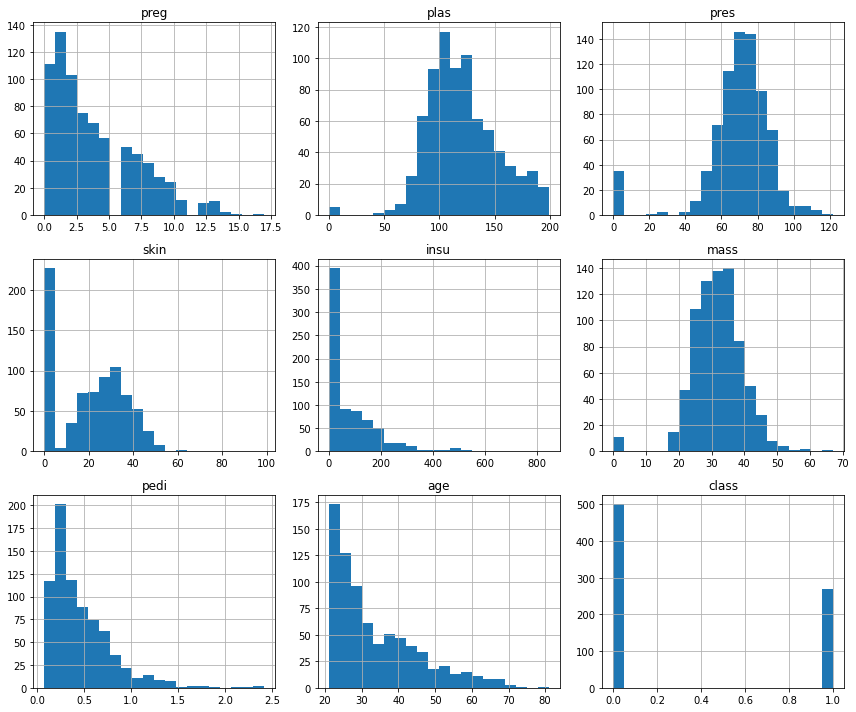

In [13]:
# Determine how the data is distributed - histogram
data1.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

### Imputation Method is Necessary to handle zero values

**MEDIAN Imputation METHOD**

Several variables contain zero values that are not medically realistic, such as:
- Blood pressure (pres)
- Skin thickness (skin)
- Insulin (insu)
- BMI (mass)

In reality, none of these measurements can be zero in a living adult.

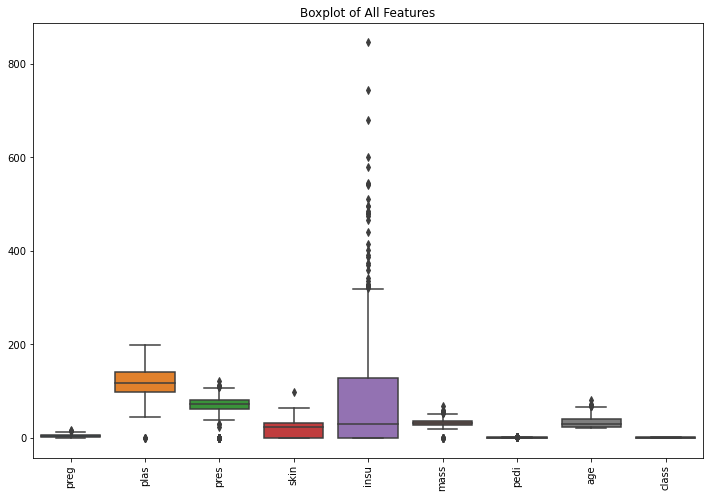

In [14]:
# Show any outliers - boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(data=data1)
plt.xticks(rotation=90)
plt.title("Boxplot of All Features")
plt.show()

In [15]:
# Correlation Matrix
corr = data1.corr()
corr

,preg,plas,pres,skin,insu,mass,pedi,age,class
preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
plas,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
pres,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
skin,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
insu,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
mass,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
pedi,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
class,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


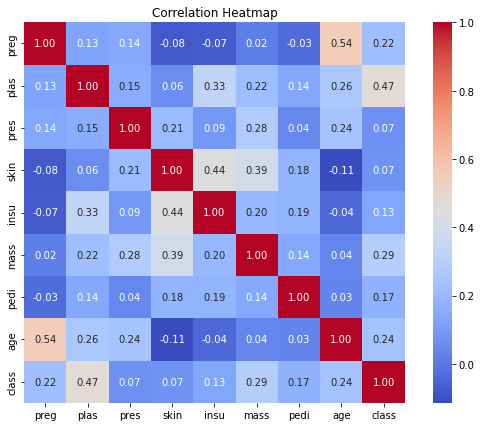

In [16]:
# Plot Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()

**Key Takeaway:**

Overall, the boxplot confirms that plasma glucose, BMI, age, and pregnancies are the most reliable features for diabetes prediction, while insulin, skin thickness, and blood pressure may contribute less due to noisy or inconsistent distributions.

**Correlation Matrix**
- Plasma Glucose Concentration (plas) is the strongest predictor of diabetes.
- BMI, age, and number of pregnancies also show moderate relationships.
- Blood pressure, skin thickness, and insulin have very weak correlations and may not help the model much.

**Box Plot**

The boxplot helps visualize how each health measurement is distributed and reveals the presence of extreme outliers. Plasma glucose shows a relatively clean distribution, which supports its strong correlation with diabetes (0.466). BMI, age, and number of pregnancies also show moderate and reasonable distributions. In contrast, insulin and skin thickness contain extreme outliers and highly skewed values, which helps explain why they show very weak correlations with diabetes.

## 1.2 Data Cleaning

In [17]:
# Columns with zero values (not medically realistic)
cols_with_zeros = ['pres', 'skin', 'insu', 'mass']

# copy the dataframe for later comparison
data2 = data1.copy()

In [18]:
# Replace zero values with NaN
for col in cols_with_zeros:
    data2[col] = data2[col].replace(0, np.nan)

In [19]:
# Confirm NaN counts after replacement
data2[cols_with_zeros].isna().sum()

pres     35
skin    227
insu    374
mass     11
dtype: int64

In [20]:
# Fill missing (NaN) values with the median of each column
data2[cols_with_zeros] = data2[cols_with_zeros].fillna(data2[cols_with_zeros].median())
data2[cols_with_zeros].describe()

,pres,skin,insu,mass
count,768.000000,768.000000,768.000000,768.000000
mean,72.386719,29.108073,140.671875,32.455208
std,12.096642,8.791221,86.383060,6.875177
min,24.000000,7.000000,14.000000,18.200000
25%,64.000000,25.000000,121.500000,27.500000
50%,72.000000,29.000000,125.000000,32.300000
75%,80.000000,32.000000,127.250000,36.600000
max,122.000000,99.000000,846.000000,67.100000


In [21]:
# Apply integer conversion to the specified columns after imputation
for col in integer_columns:
    if col in data2.columns and data2[col].dtype == 'float64':
        data2[col] = data2[col].astype('int64')

print("Data types after selective conversion to int64:")
print(data2.info())
data2.head()

Data types after selective conversion to int64:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


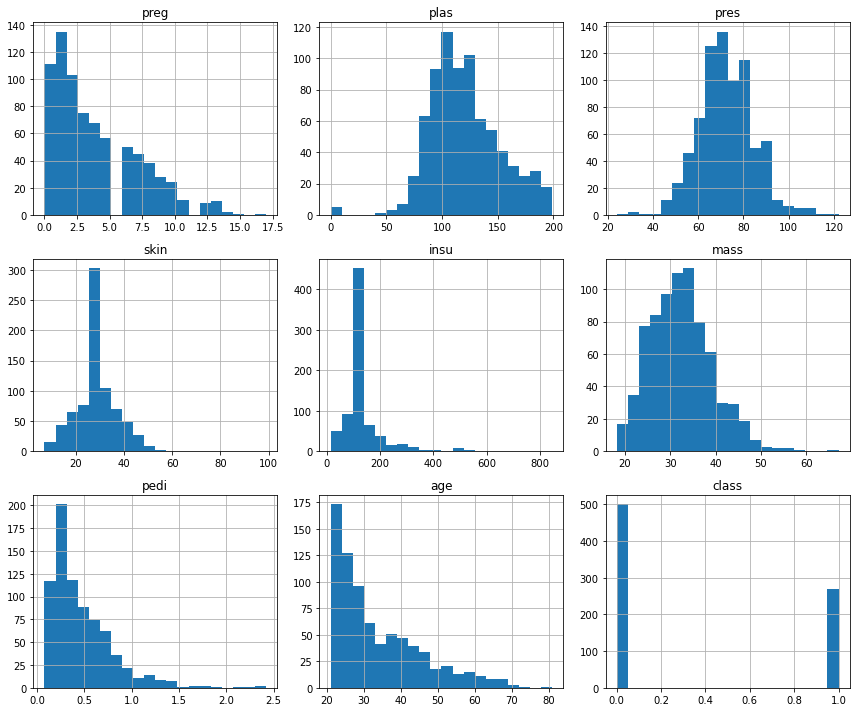

In [22]:
# Replot histogram after imputation
data2.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

In [23]:
# Rerun correlation matrix after imputation
corr = data2.corr()
corr

,preg,plas,pres,skin,insu,mass,pedi,age,class
preg,1.000000,0.129459,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
plas,0.129459,1.000000,0.217870,0.182037,0.409283,0.218487,0.137337,0.263514,0.466581
pres,0.208615,0.217870,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
skin,0.081770,0.182037,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
insu,0.025047,0.409283,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
mass,0.021559,0.218487,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
pedi,-0.033523,0.137337,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
age,0.544341,0.263514,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
class,0.221898,0.466581,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


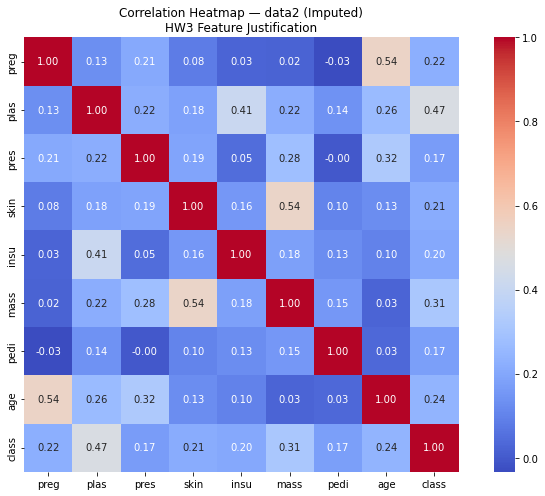


Correlation with target 'class' — sorted descending:
class    1.000000
plas     0.466581
mass     0.312038
age      0.238356
preg     0.221898
skin     0.214873
insu     0.203790
pedi     0.173844
pres     0.165723


In [24]:
# Plot updated heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap — data2 (Imputed)\nHW3 Feature Justification")
plt.tight_layout()
plt.show()

print("\nCorrelation with target 'class' — sorted descending:")
print(corr['class'].sort_values(ascending=False).to_string())

## 1.3 Key Takeaways

- The imputed dataset provides more accurate relationships and the correlation matrix now reflects real physiological relationships.
- Glucose, BMI, insulin, age, skin thickness, and pregnancies are the strongest predictors.
- Blood pressure and pedigree function are weaker but still usable.
- Median imputation improved the quality of the data significantly, especially for: insulin, skin, BMI, and blood pressure.

**Feature Justification for HW3:**

All 8 features are retained. Random Forest and Decision Trees are tree-based ensemble methods that internally handle feature importance ranking — they are not distance-based like KNN, so scaling is less critical, but all features will be fed in and the models will naturally learn to weight weaker features lower. Feature importance plots will be generated post-training to confirm which features drove the models' decisions.

## 1.4 Final Dataset

In [25]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [26]:
data2.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
# Rename columns for readability in reports
new_column_names = [
    'Number of times pregnant',
    'Plasma glucose concentration a 2 hours in an oral glucose tolerance test',
    'Diastolic blood pressure (mm Hg)',
    'Triceps skin fold thickness (mm)',
    '2-Hour serum insulin (mu U/ml)',
    'Body mass index (weight in kg/(height in m)^2)',
    'Diabetes pedigree function',
    'Age (years)',
    'Class variable'
]

cleaned = data2.copy()
cleaned.columns = new_column_names
cleaned.head()

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
## 2. Homework 3 — Random Forest & Decision Tree Classification
### COEG 435/535 · Fall 2026

| Step | Requirement | Section |
|---|---|---|
| (i) | Last 50 observations as hold-out test set | 2.2 |
| (ii) | Pre-processing (scaling, already imputed) | 2.3 |
| (iii) | 65/35, 70/30 splits | 2.4 |
| (iv) | Hyperparameter tuning for DT and RF | 2.5, 2.9 |
| (v) | Confusion matrix, precision, accuracy | 2.6, 2.10 |
| (vi) | Differences across splits and hyperparameters | 2.7, 2.11, 2.13 |
| (vii) | English narrative at every stage | All markdown cells |
| (viii) | Correlation heatmap | 1.3 |
| (ix) | Fully commented code — this notebook is the appendix | All code cells |

**Question 1 → Decision Tree · Question 2 → Random Forest**

## 2.0 Models

In [28]:
print("Working from data2 — shape:", data2.shape)
data2.head()

Working from data2 — shape: (768, 9)


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2.1 Step (viii) — Feature Justification via Correlation Heatmap

Before training, we confirm which features carry the most predictive signal by inspecting the correlation heatmap on data2 — the fully imputed dataset from Section 1.2.

| Feature | r with class | Interpretation |
|---|---|---|
| plas | 0.47 | Plasma glucose — dominant predictor |
| mass | 0.31 | BMI |
| age | 0.24 | Older age → higher risk |
| preg | 0.22 | More pregnancies → higher risk |
| skin | 0.21 | Triceps skinfold thickness |
| insu | 0.20 | Serum insulin |
| pres | 0.17 | Blood pressure |
| pedi | 0.17 | Diabetes pedigree function |

**Decision:** All 8 features are retained. Unlike KNN, tree-based models perform internal feature selection through the splitting process. Random Forest additionally uses feature bagging, which reduces the influence of weaker features automatically. Post-training feature importance plots will validate this decision.

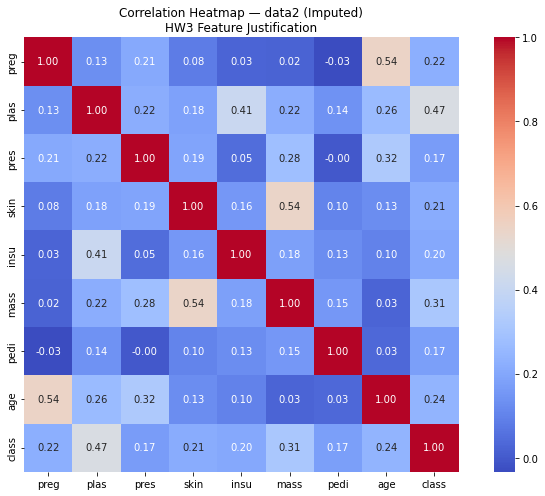


Correlation with target 'class' — sorted descending:
class    1.000000
plas     0.466581
mass     0.312038
age      0.238356
preg     0.221898
skin     0.214873
insu     0.203790
pedi     0.173844
pres     0.165723


In [29]:
# Step (viii): Heatmap on data2 for feature justification
corr_hw = data2.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_hw, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap — data2 (Imputed)\nHW3 Feature Justification')
plt.tight_layout()
plt.show()

print("\nCorrelation with target 'class' — sorted descending:")
print(corr_hw['class'].sort_values(ascending=False).to_string())

## 2.2 Step (i) — Reserve Last 50 Observations as Final Hold-Out Test Set

In [30]:
# Step (i): Carve out the last 50 rows as an untouched hold-out test set
final_test = data2.iloc[-50:].copy()   # rows 718-767
remaining  = data2.iloc[:-50].copy()   # rows 0-717

X_test_final = final_test.drop(columns='class')
y_test_final = final_test['class']

print(f"Hold-out test set : {len(final_test)} rows")
print(f"Remaining dataset : {len(remaining)} rows")
print(f"\nClass distribution in hold-out set:")
print(y_test_final.value_counts().rename({0: 'No Diabetes', 1: 'Diabetes'}))

Hold-out test set : 50 rows
Remaining dataset : 718 rows

Class distribution in hold-out set:
No Diabetes    31
Diabetes       19
Name: class, dtype: int64


## 2.3 Step (ii) — Pre-processing

In [31]:
# Step (ii): Separate features and target from the 718 remaining rows
X_remaining = remaining.drop(columns='class')
y_remaining = remaining['class']

print("Features used:", X_remaining.columns.tolist())
print(f"\nClass distribution in remaining {len(remaining)} rows:")
print(y_remaining.value_counts().rename({0: 'No Diabetes', 1: 'Diabetes'}))

Features used: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

Class distribution in remaining 718 rows:
No Diabetes    469
Diabetes       249
Name: class, dtype: int64


## 2.4 Step (iii) — Define Train / Validation Splits

Two splits are applied to the 718 remaining rows.

| Split | Train rows (~) | Val rows (~) |
|---|---|---|
| 65/35 | 467 | 251 |
| 70/30 | 503 | 215 |

`random_state=42` ensures reproducibility. `stratify=y_remaining` preserves the class ratio in every partition so no split accidentally contains only one class.

In [32]:
# Step (iii): Build both stratified train/validation splits
SPLITS = [0.65, 0.70]
RANDOM_STATE = 42

split_data = {}
for train_frac in SPLITS:
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_remaining, y_remaining,
        train_size=train_frac,
        random_state=RANDOM_STATE,
        stratify=y_remaining  # preserve class balance in every split
    )
    split_data[train_frac] = (X_tr, X_val, y_tr, y_val)
    print(f"Split {int(train_frac*100)}/{int((1-train_frac)*100)} — "
          f"Train: {len(X_tr)}, Val: {len(X_val)}")

Split 65/35 — Train: 466, Val: 252
Split 70/30 — Train: 502, Val: 216


---
# Question 1 — Decision Tree

## 2.5 Hyperparameter Tuning — Decision Tree

**How Decision Trees work:**
A Decision Tree recursively partitions the feature space by selecting the feature and threshold that best separates the classes at each node. Splitting continues until a stopping criterion is met (e.g., max depth or minimum samples).

- `max_depth`: Controls how deep the tree can grow. Shallow trees underfit; very deep trees overfit.
- `criterion`: The function used to measure split quality. `gini` measures impurity; `entropy` measures information gain.
- `min_samples_split`: Minimum samples required to split an internal node — higher values prevent overfitting.

Since the assignment references 'different versions of k and split percentage' — language carried over from HW2 — for tree-based models this is interpreted as varying the key hyperparameters above across the two splits.

In [33]:
# Hyperparameter grid for Decision Tree
dt_max_depths = [None, 3, 5, 10]
dt_criteria   = ['gini', 'entropy']

dt_results = []

for train_frac, (X_tr, X_val, y_tr, y_val) in split_data.items():
    split_label = f"{int(train_frac*100)}/{int((1-train_frac)*100)}"

    # Fit scaler on training data only — apply to val (prevents leakage)
    scaler = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)

    for depth in dt_max_depths:
        for crit in dt_criteria:
            dt = DecisionTreeClassifier(
                max_depth=depth,
                criterion=crit,
                random_state=RANDOM_STATE
            )
            dt.fit(X_tr_s, y_tr)
            y_pred = dt.predict(X_val_s)

            cm   = confusion_matrix(y_val, y_pred)
            acc  = accuracy_score(y_val, y_pred)
            prec = precision_score(y_val, y_pred, zero_division=0)

            dt_results.append({
                'Split'    : split_label,
                'max_depth': str(depth),   # str so 'None' displays cleanly
                'criterion': crit,
                'Accuracy' : round(acc, 4),
                'Precision': round(prec, 4),
                'TN': cm[0,0], 'FP': cm[0,1],
                'FN': cm[1,0], 'TP': cm[1,1]
            })

dt_df = pd.DataFrame(dt_results)
print("=== Decision Tree Validation Results — All Splits × All Hyperparameters ===")
dt_df

=== Decision Tree Validation Results — All Splits × All Hyperparameters ===


,Split,max_depth,criterion,Accuracy,Precision,TN,FP,FN,TP
0,65/35,None,gini,0.6944,0.5610,129,36,41,46
1,65/35,None,entropy,0.7460,0.6386,135,30,34,53
2,65/35,3,gini,0.7381,0.7561,155,10,56,31
3,65/35,3,entropy,0.7460,0.7949,157,8,56,31
4,65/35,5,gini,0.7063,0.6182,144,21,53,34
5,65/35,5,entropy,0.7143,0.6471,147,18,54,33
6,65/35,10,gini,0.6984,0.5663,129,36,40,47
7,65/35,10,entropy,0.7103,0.6000,137,28,45,42
8,70/30,None,gini,0.6852,0.5538,112,29,39,36
9,70/30,None,entropy,0.6898,0.5714,117,24,43,32


## 2.6 Step (v) — Confusion Matrices for Decision Tree

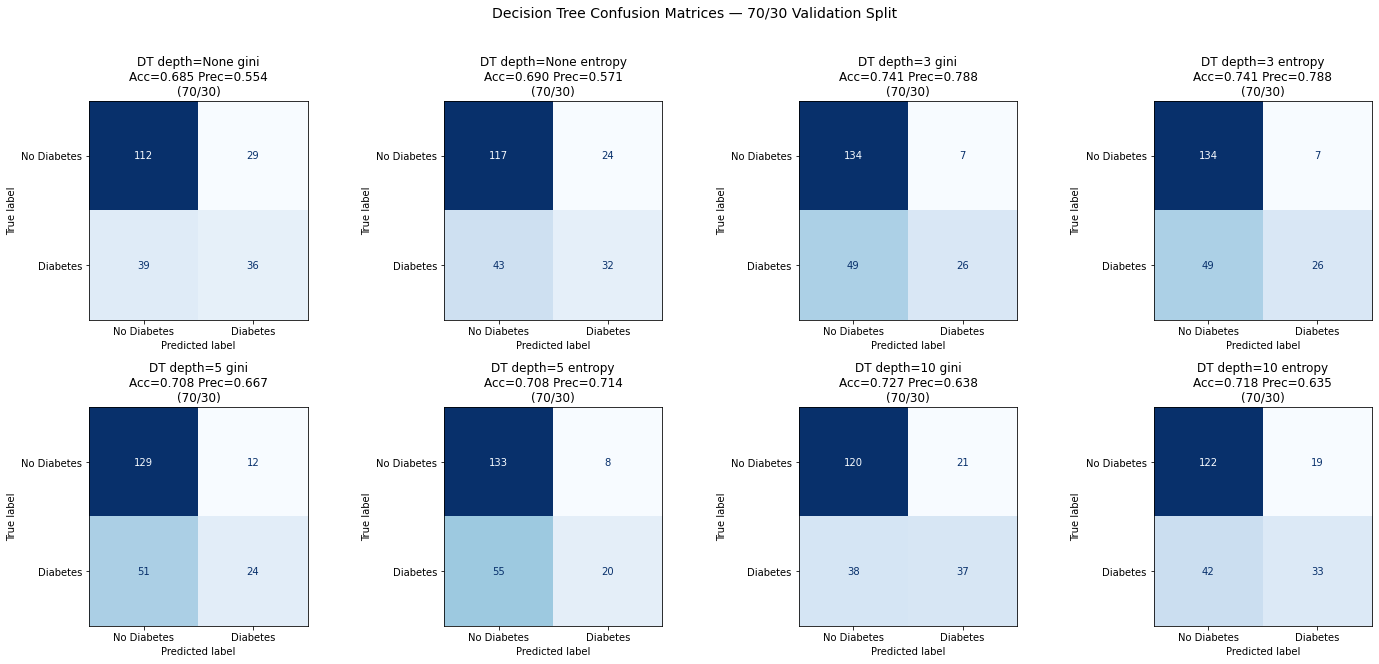

In [34]:
# Step (v): confusion matrices for DT — gini criterion, 70/30 split, all max_depth values
DEMO_SPLIT = 0.70
X_tr_d, X_val_d, y_tr_d, y_val_d = split_data[DEMO_SPLIT]

scaler_d  = StandardScaler()
X_tr_ds   = scaler_d.fit_transform(X_tr_d)
X_val_ds  = scaler_d.transform(X_val_d)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

idx = 0
for depth in dt_max_depths:
    for crit in dt_criteria:
        dt = DecisionTreeClassifier(max_depth=depth, criterion=crit, random_state=RANDOM_STATE)
        dt.fit(X_tr_ds, y_tr_d)
        y_pred = dt.predict(X_val_ds)

        cm   = confusion_matrix(y_val_d, y_pred)
        acc  = accuracy_score(y_val_d, y_pred)
        prec = precision_score(y_val_d, y_pred, zero_division=0)

        disp = ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes'])
        disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
        axes[idx].set_title(f"DT depth={depth} {crit}\nAcc={acc:.3f} Prec={prec:.3f}\n(70/30)")
        idx += 1

plt.suptitle("Decision Tree Confusion Matrices — 70/30 Validation Split", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2.7 Step (vi) — Decision Tree Comparison Across Splits and Hyperparameters

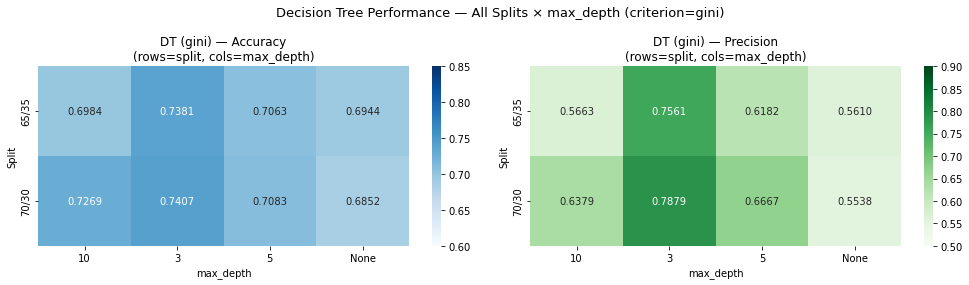

In [35]:
# Heatmap: DT accuracy across max_depth x split (gini only for clarity)
dt_gini = dt_df[dt_df['criterion'] == 'gini'].copy()
dt_pivot_acc  = dt_gini.pivot(index='Split', columns='max_depth', values='Accuracy')
dt_pivot_prec = dt_gini.pivot(index='Split', columns='max_depth', values='Precision')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(dt_pivot_acc,  annot=True, fmt='.4f', cmap='Blues',  ax=axes[0], vmin=0.60, vmax=0.85)
axes[0].set_title("DT (gini) — Accuracy\n(rows=split, cols=max_depth)")

sns.heatmap(dt_pivot_prec, annot=True, fmt='.4f', cmap='Greens', ax=axes[1], vmin=0.50, vmax=0.90)
axes[1].set_title("DT (gini) — Precision\n(rows=split, cols=max_depth)")

plt.suptitle("Decision Tree Performance — All Splits × max_depth (criterion=gini)", fontsize=13)
plt.tight_layout()
plt.show()

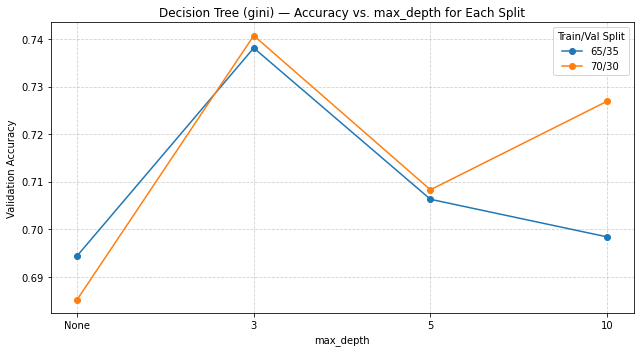

In [36]:
# Line plot: DT accuracy vs max_depth per split
plt.figure(figsize=(9, 5))
for split_label in dt_gini['Split'].unique():
    subset = dt_gini[dt_gini['Split'] == split_label]
    plt.plot(subset['max_depth'], subset['Accuracy'], marker='o', label=split_label)

plt.title("Decision Tree (gini) — Accuracy vs. max_depth for Each Split")
plt.xlabel("max_depth")
plt.ylabel("Validation Accuracy")
plt.legend(title="Train/Val Split")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 2.8 Best Decision Tree — Final Model on Hold-Out Test Set (n = 50)

Best DT — Split: 65/35, max_depth: None, criterion: entropy
Validation Accuracy : 0.746
Validation Precision: 0.6386

=== Best Decision Tree — Final Hold-Out Test Set (n=50) ===
              precision    recall  f1-score   support

 No Diabetes       0.77      0.87      0.82        31
    Diabetes       0.73      0.58      0.65        19

    accuracy                           0.76        50
   macro avg       0.75      0.72      0.73        50
weighted avg       0.76      0.76      0.75        50



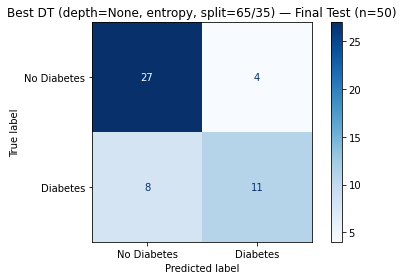

In [37]:
# Select best DT configuration by validation accuracy
best_dt_row   = dt_df.loc[dt_df['Accuracy'].idxmax()]
best_dt_split = float(best_dt_row['Split'].split('/')[0]) / 100
best_dt_depth = None if best_dt_row['max_depth'] == 'None' else int(best_dt_row['max_depth'])
best_dt_crit  = best_dt_row['criterion']

print(f"Best DT — Split: {best_dt_row['Split']}, max_depth: {best_dt_depth}, criterion: {best_dt_crit}")
print(f"Validation Accuracy : {best_dt_row['Accuracy']}")
print(f"Validation Precision: {best_dt_row['Precision']}")

# Retrain best DT on its training fold, evaluate on untouched 50-row test set
X_tr_b, _, y_tr_b, _ = split_data[best_dt_split]
scaler_b = StandardScaler()
X_tr_bs        = scaler_b.fit_transform(X_tr_b)
X_test_final_s = scaler_b.transform(X_test_final)

best_dt = DecisionTreeClassifier(
    max_depth=best_dt_depth,
    criterion=best_dt_crit,
    random_state=RANDOM_STATE
)
best_dt.fit(X_tr_bs, y_tr_b)
y_final_pred_dt = best_dt.predict(X_test_final_s)

print("\n=== Best Decision Tree — Final Hold-Out Test Set (n=50) ===")
print(classification_report(y_test_final, y_final_pred_dt,
                             target_names=['No Diabetes', 'Diabetes']))

cm_dt_final = confusion_matrix(y_test_final, y_final_pred_dt)
ConfusionMatrixDisplay(cm_dt_final, display_labels=['No Diabetes', 'Diabetes']).plot(cmap='Blues')
plt.title(f"Best DT (depth={best_dt_depth}, {best_dt_crit}, split={best_dt_row['Split']}) — Final Test (n=50)")
plt.tight_layout()
plt.show()

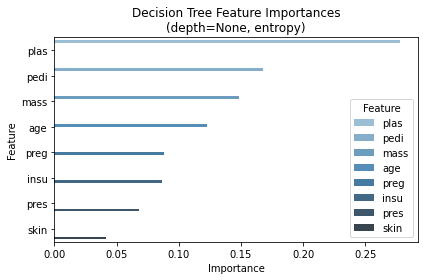

In [39]:
# Feature importance — Decision Tree
feat_names = X_remaining.columns
dt_importances = pd.DataFrame({
    'Feature': feat_names,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=dt_importances, x='Importance', y='Feature', hue='Feature',
            palette='Blues_d')
plt.title(f"Decision Tree Feature Importances\n(depth={best_dt_depth}, {best_dt_crit})")
plt.tight_layout()
plt.show()

---
# Question 2 — Random Forest

## 2.9 Hyperparameter Tuning — Random Forest

**How Random Forest works:**
Random Forest builds an ensemble of Decision Trees, each trained on a random bootstrap sample of the data and a random subset of features at each split. Final predictions are made by majority vote across all trees.

- `n_estimators`: Number of trees in the forest. More trees generally improve stability but increase compute time.
- `max_depth`: Maximum depth of each tree. Unconstrained (`None`) lets trees fully grow.
- `max_features`: Number of features considered at each split — `'sqrt'` is the standard for classification.

Unlike KNN's k parameter, Random Forest hyperparameters control the ensemble size and individual tree complexity. The same two splits from Section 2.4 are reused.

In [40]:
# Hyperparameter grid for Random Forest
rf_n_estimators = [50, 100, 200]
rf_max_depths   = [None, 5, 10]

rf_results = []

for train_frac, (X_tr, X_val, y_tr, y_val) in split_data.items():
    split_label = f"{int(train_frac*100)}/{int((1-train_frac)*100)}"

    scaler = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)

    for n_est in rf_n_estimators:
        for depth in rf_max_depths:
            rf = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                max_features='sqrt',
                random_state=RANDOM_STATE
            )
            rf.fit(X_tr_s, y_tr)
            y_pred = rf.predict(X_val_s)

            cm   = confusion_matrix(y_val, y_pred)
            acc  = accuracy_score(y_val, y_pred)
            prec = precision_score(y_val, y_pred, zero_division=0)

            rf_results.append({
                'Split'       : split_label,
                'n_estimators': n_est,
                'max_depth'   : str(depth),
                'Accuracy'    : round(acc, 4),
                'Precision'   : round(prec, 4),
                'TN': cm[0,0], 'FP': cm[0,1],
                'FN': cm[1,0], 'TP': cm[1,1]
            })

rf_df = pd.DataFrame(rf_results)
print("=== Random Forest Validation Results — All Splits × All Hyperparameters ===")
rf_df

=== Random Forest Validation Results — All Splits × All Hyperparameters ===


,Split,n_estimators,max_depth,Accuracy,Precision,TN,FP,FN,TP
0,65/35,50,None,0.7302,0.6377,140,25,43,44
1,65/35,50,5,0.7579,0.7321,150,15,46,41
2,65/35,50,10,0.7619,0.7213,148,17,43,44
3,65/35,100,None,0.7579,0.6912,144,21,40,47
4,65/35,100,5,0.7540,0.7193,149,16,46,41
5,65/35,100,10,0.7659,0.7188,147,18,41,46
6,65/35,200,None,0.7540,0.6866,144,21,41,46
7,65/35,200,5,0.7540,0.7193,149,16,46,41
8,65/35,200,10,0.7500,0.6935,146,19,44,43
9,70/30,50,None,0.7731,0.7500,128,13,36,39


## 2.10 Step (v) — Confusion Matrices for Random Forest

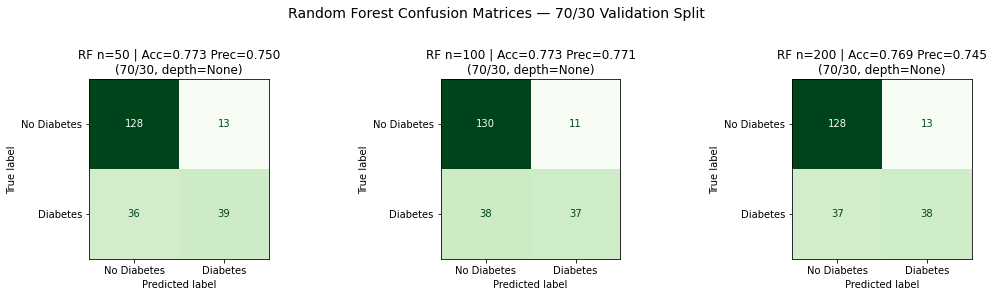

In [41]:
# Step (v): confusion matrices for RF — 70/30 split, all n_estimators at max_depth=None
X_tr_d, X_val_d, y_tr_d, y_val_d = split_data[0.70]
scaler_d = StandardScaler()
X_tr_ds  = scaler_d.fit_transform(X_tr_d)
X_val_ds = scaler_d.transform(X_val_d)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, n_est in enumerate(rf_n_estimators):
    rf = RandomForestClassifier(n_estimators=n_est, max_depth=None,
                                max_features='sqrt', random_state=RANDOM_STATE)
    rf.fit(X_tr_ds, y_tr_d)
    y_pred = rf.predict(X_val_ds)

    cm   = confusion_matrix(y_val_d, y_pred)
    acc  = accuracy_score(y_val_d, y_pred)
    prec = precision_score(y_val_d, y_pred, zero_division=0)

    disp = ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Greens')
    axes[idx].set_title(f"RF n={n_est} | Acc={acc:.3f} Prec={prec:.3f}\n(70/30, depth=None)")

plt.suptitle("Random Forest Confusion Matrices — 70/30 Validation Split", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2.11 Step (vi) — Random Forest Comparison Across Splits and Hyperparameters

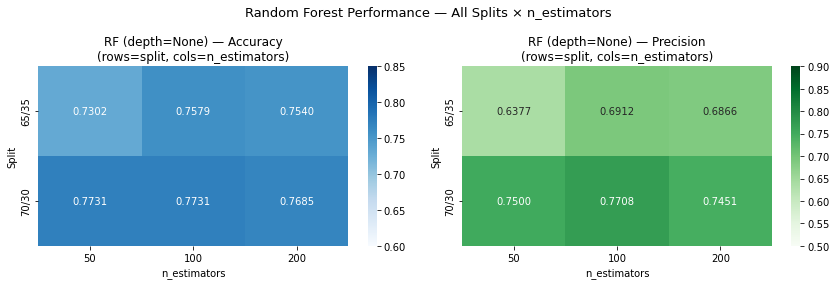

In [42]:
# Heatmap: RF accuracy across n_estimators x split (max_depth=None)
rf_none = rf_df[rf_df['max_depth'] == 'None'].copy()
rf_pivot_acc  = rf_none.pivot(index='Split', columns='n_estimators', values='Accuracy')
rf_pivot_prec = rf_none.pivot(index='Split', columns='n_estimators', values='Precision')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(rf_pivot_acc,  annot=True, fmt='.4f', cmap='Blues',  ax=axes[0], vmin=0.60, vmax=0.85)
axes[0].set_title("RF (depth=None) — Accuracy\n(rows=split, cols=n_estimators)")

sns.heatmap(rf_pivot_prec, annot=True, fmt='.4f', cmap='Greens', ax=axes[1], vmin=0.50, vmax=0.90)
axes[1].set_title("RF (depth=None) — Precision\n(rows=split, cols=n_estimators)")

plt.suptitle("Random Forest Performance — All Splits × n_estimators", fontsize=13)
plt.tight_layout()
plt.show()

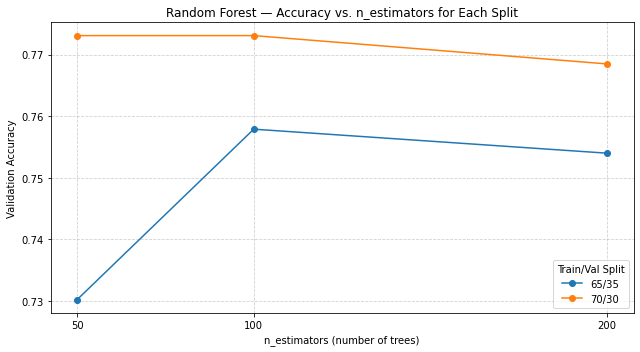

In [43]:
# Line plot: RF accuracy vs n_estimators per split (max_depth=None)
plt.figure(figsize=(9, 5))
for split_label in rf_none['Split'].unique():
    subset = rf_none[rf_none['Split'] == split_label]
    plt.plot(subset['n_estimators'], subset['Accuracy'], marker='o', label=split_label)

plt.title("Random Forest — Accuracy vs. n_estimators for Each Split")
plt.xlabel("n_estimators (number of trees)")
plt.ylabel("Validation Accuracy")
plt.legend(title="Train/Val Split")
plt.xticks(rf_n_estimators)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 2.12 Best Random Forest — Final Model on Hold-Out Test Set (n = 50)

Best RF — Split: 70/30, n_estimators: 50, max_depth: None
Validation Accuracy : 0.7731
Validation Precision: 0.75

=== Best Random Forest — Final Hold-Out Test Set (n=50) ===
              precision    recall  f1-score   support

 No Diabetes       0.78      0.94      0.85        31
    Diabetes       0.85      0.58      0.69        19

    accuracy                           0.80        50
   macro avg       0.81      0.76      0.77        50
weighted avg       0.81      0.80      0.79        50



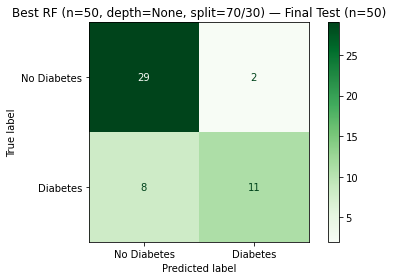

In [44]:
# Select best RF configuration by validation accuracy
best_rf_row   = rf_df.loc[rf_df['Accuracy'].idxmax()]
best_rf_split = float(best_rf_row['Split'].split('/')[0]) / 100
best_rf_n     = int(best_rf_row['n_estimators'])
best_rf_depth = None if best_rf_row['max_depth'] == 'None' else int(best_rf_row['max_depth'])

print(f"Best RF — Split: {best_rf_row['Split']}, n_estimators: {best_rf_n}, max_depth: {best_rf_depth}")
print(f"Validation Accuracy : {best_rf_row['Accuracy']}")
print(f"Validation Precision: {best_rf_row['Precision']}")

X_tr_b, _, y_tr_b, _ = split_data[best_rf_split]
scaler_b = StandardScaler()
X_tr_bs        = scaler_b.fit_transform(X_tr_b)
X_test_final_s = scaler_b.transform(X_test_final)

best_rf = RandomForestClassifier(
    n_estimators=best_rf_n,
    max_depth=best_rf_depth,
    max_features='sqrt',
    random_state=RANDOM_STATE
)
best_rf.fit(X_tr_bs, y_tr_b)
y_final_pred_rf = best_rf.predict(X_test_final_s)

print("\n=== Best Random Forest — Final Hold-Out Test Set (n=50) ===")
print(classification_report(y_test_final, y_final_pred_rf,
                             target_names=['No Diabetes', 'Diabetes']))

cm_rf_final = confusion_matrix(y_test_final, y_final_pred_rf)
ConfusionMatrixDisplay(cm_rf_final, display_labels=['No Diabetes', 'Diabetes']).plot(cmap='Greens')
plt.title(f"Best RF (n={best_rf_n}, depth={best_rf_depth}, split={best_rf_row['Split']}) — Final Test (n=50)")
plt.tight_layout()
plt.show()

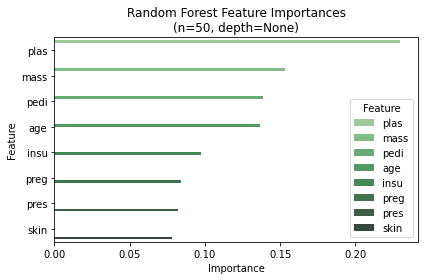

In [46]:
# Feature importance — Random Forest
rf_importances = pd.DataFrame({
    'Feature'   : feat_names,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=rf_importances, x='Importance', y='Feature', hue='Feature',
            palette='Greens_d')
plt.title(f"Random Forest Feature Importances\n(n={best_rf_n}, depth={best_rf_depth})")
plt.tight_layout()
plt.show()

---
## 2.13 Combined Summary — Decision Tree vs. Random Forest (All Splits)

Side-by-side bar charts compare both algorithms across both splits. Decision Tree is shown at `max_depth=5, gini` and Random Forest at `n_estimators=100, depth=None` as representative mid-range configurations. The full leaderboard below ranks every configuration by validation accuracy.

=== DT (depth=5, gini) vs RF (n=100, depth=None) — Validation Performance ===
Split  DT_Acc  DT_Prec  RF_Acc  RF_Prec
65/35  0.7063   0.6182  0.7579   0.6912
70/30  0.7083   0.6667  0.7731   0.7708


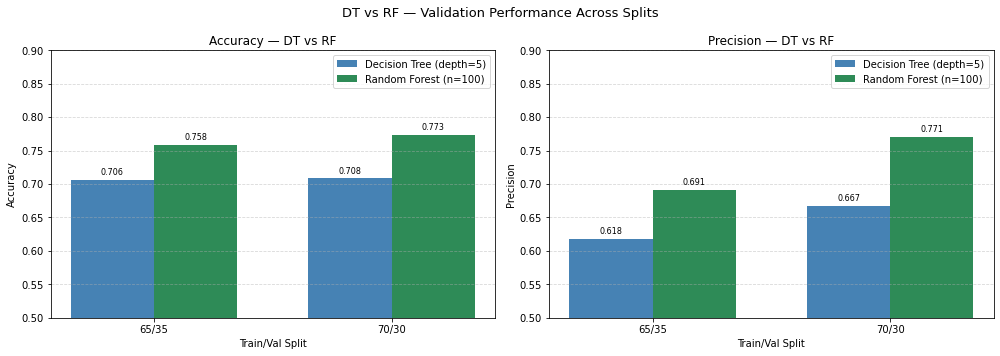

In [47]:
# Combined comparison — DT (depth=5, gini) vs RF (n=100, depth=None)
dt_rep = (dt_df[(dt_df['max_depth'] == '5') & (dt_df['criterion'] == 'gini')]
          [['Split', 'Accuracy', 'Precision']]
          .rename(columns={'Accuracy': 'DT_Acc', 'Precision': 'DT_Prec'})
          .reset_index(drop=True))

rf_rep = (rf_df[(rf_df['n_estimators'] == 100) & (rf_df['max_depth'] == 'None')]
          [['Split', 'Accuracy', 'Precision']]
          .rename(columns={'Accuracy': 'RF_Acc', 'Precision': 'RF_Prec'})
          .reset_index(drop=True))

combined = dt_rep.merge(rf_rep, on='Split')
print("=== DT (depth=5, gini) vs RF (n=100, depth=None) — Validation Performance ===")
print(combined.to_string(index=False))

x     = np.arange(len(combined))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dt_col, rf_col, title in [
    (axes[0], 'DT_Acc',  'RF_Acc',  'Accuracy'),
    (axes[1], 'DT_Prec', 'RF_Prec', 'Precision'),
]:
    b1 = ax.bar(x - width/2, combined[dt_col], width, label='Decision Tree (depth=5)', color='steelblue')
    b2 = ax.bar(x + width/2, combined[rf_col], width, label='Random Forest (n=100)',  color='seagreen')
    ax.set_title(f"{title} — DT vs RF")
    ax.set_xlabel("Train/Val Split")
    ax.set_ylabel(title)
    ax.set_xticks(x)
    ax.set_xticklabels(combined['Split'])
    ax.set_ylim(0.50, 0.90)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle("DT vs RF — Validation Performance Across Splits", fontsize=13)
plt.tight_layout()
plt.show()

In [48]:
# Full leaderboard — all DT + all RF configurations ranked by validation accuracy
dt_board = dt_df[['Split', 'max_depth', 'criterion', 'Accuracy', 'Precision']].copy()
dt_board.insert(0, 'Algorithm', dt_board.apply(
    lambda r: f"DT (depth={r['max_depth']}, {r['criterion']})", axis=1))
dt_board = dt_board[['Algorithm', 'Split', 'Accuracy', 'Precision']]

rf_board = rf_df[['Split', 'n_estimators', 'max_depth', 'Accuracy', 'Precision']].copy()
rf_board.insert(0, 'Algorithm', rf_board.apply(
    lambda r: f"RF (n={r['n_estimators']}, depth={r['max_depth']})", axis=1))
rf_board = rf_board[['Algorithm', 'Split', 'Accuracy', 'Precision']]

leaderboard = (pd.concat([dt_board, rf_board], ignore_index=True)
               .sort_values('Accuracy', ascending=False)
               .reset_index(drop=True))

print("=== Full Leaderboard — Ranked by Validation Accuracy ===")
leaderboard

=== Full Leaderboard — Ranked by Validation Accuracy ===


,Algorithm,Split,Accuracy,Precision
0,"RF (n=100, depth=5)",70/30,0.7731,0.7708
1,"RF (n=100, depth=None)",70/30,0.7731,0.7708
2,"RF (n=50, depth=5)",70/30,0.7731,0.7708
3,"RF (n=50, depth=None)",70/30,0.7731,0.7500
4,"RF (n=200, depth=5)",70/30,0.7685,0.7551
5,"RF (n=200, depth=None)",70/30,0.7685,0.7451
6,"RF (n=100, depth=10)",65/35,0.7659,0.7188
7,"RF (n=50, depth=10)",70/30,0.7639,0.7400
8,"RF (n=50, depth=10)",65/35,0.7619,0.7213
9,"RF (n=200, depth=10)",70/30,0.7593,0.7347
